# STUDI KASUS 2
# Pemodelan Konsentrasi CO₂ Atmosfer Menggunakan Metode Runge-Kutta Orde 4 (RK4)

**KELOMPOK 10**  
- Fadila Amalia (101042400043)
- Alfania Surbakti (101042400046)

**Mata Kuliah :** Teknik Komputasi

---

## Tujuan
Menganalisis hubungan emisi CO₂ global terhadap konsentrasi CO₂ atmosfer menggunakan metode Runge-Kutta Orde 4.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 12

In [29]:
from google.colab import files

uploaded = files.upload()

Saving co2_annmean_mlo.csv to co2_annmean_mlo (5).csv
Saving annual-co2-emissions-per-country (1).csv to annual-co2-emissions-per-country (1) (4).csv


In [52]:
co2 = pd.read_csv(
    'co2_annmean_mlo (3).csv',
    sep=',',
    comment='#',
    header=None,
    names=['year', 'mean', 'unc']
)

co2['year'] = pd.to_numeric(co2['year'], errors='coerce')
co2['mean'] = pd.to_numeric(co2['mean'], errors='coerce')
co2['unc'] = pd.to_numeric(co2['unc'], errors='coerce')

co2 = co2.dropna(subset=['year'])

co2 = co2.rename(columns={
    'year':'Year',
    'mean':'CO2',
    'unc':'unc'
})

co2.head()

,Year,CO2,unc
1,1959.0,315.98,0.12
2,1960.0,316.91,0.12
3,1961.0,317.64,0.12
4,1962.0,318.45,0.12
5,1963.0,318.99,0.12


In [31]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=co2)

https://docs.google.com/spreadsheets/d/1-03tfULM9VoJwxAoIf7C7xOXbYbc-wvnkPrJ9ASUTtc/edit#gid=0


In [53]:
emisi = pd.read_csv(
    'annual-co2-emissions-per-country (1) (2).csv'
)

emisi.head()

,Entity,Code,Year,Annual CO₂ emissions
0,Afghanistan,AFG,1949,14656.0
1,Afghanistan,AFG,1950,84272.0
2,Afghanistan,AFG,1951,91600.0
3,Afghanistan,AFG,1952,91600.0
4,Afghanistan,AFG,1953,106256.0


In [33]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=emisi)

https://docs.google.com/spreadsheets/d/1lDLQx6lQ40wvFB-MAoZet9bz8YGLLTJYIiA33m5XOZQ/edit#gid=0


In [55]:
if 'Annual CO₂ emissions' in emisi.columns:
    kolom_emisi = 'Annual CO₂ emissions'

elif 'Annual COâ‚‚ emissions' in emisi.columns:
    kolom_emisi = 'Annual COâ‚‚ emissions'

else:
    print(emisi.columns)

In [56]:
world = emisi[
    emisi['Entity'] == 'World'
].copy()

world = world.dropna(
    subset=[kolom_emisi]
)

world['Year'] = pd.to_numeric(
    world['Year']
)

world[kolom_emisi] = pd.to_numeric(
    world[kolom_emisi]
)

world.head()

,Entity,Code,Year,Annual CO₂ emissions
28837,World,OWID_WRL,1750,9305937.0
28838,World,OWID_WRL,1751,9407229.0
28839,World,OWID_WRL,1752,9505168.0
28840,World,OWID_WRL,1753,9610490.0
28841,World,OWID_WRL,1754,9733580.0


In [57]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=world)

https://docs.google.com/spreadsheets/d/1Khxuswcr26qQI4zEtSC-89_vHx_Ed13oP1SY0vbY-uQ/edit#gid=0


In [42]:
df = pd.merge(
    co2[['Year', 'CO2']],
    world[['Year', kolom_emisi]],
    on='Year',
    how='inner'
)

df = df.sort_values(
    'Year'
).reset_index(drop=True)

df['Emisi_GtCO2'] = (
    df[kolom_emisi] / 1e9
)

df.head()

,Year,CO2,Annual CO₂ emissions,Emisi_GtCO2
0,1959.0,315.98,8.855113e+09,8.855113
1,1960.0,316.91,9.386952e+09,9.386952
2,1961.0,317.64,9.414990e+09,9.414990
3,1962.0,318.45,9.747241e+09,9.747241
4,1963.0,318.99,1.026678e+10,10.266778


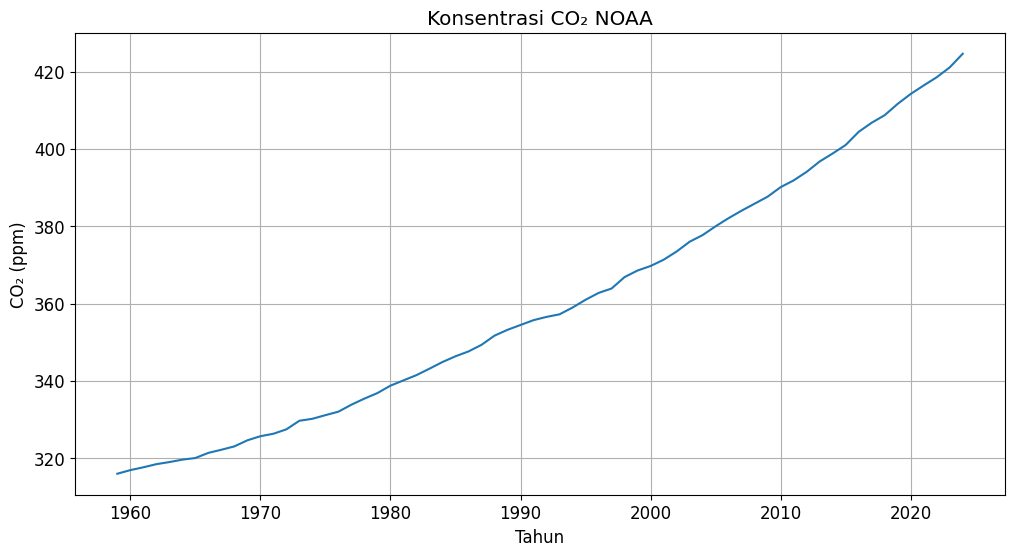

In [43]:
plt.plot(df['Year'], df['CO2'])

plt.title("Konsentrasi CO₂ NOAA")
plt.xlabel("Tahun")
plt.ylabel("CO₂ (ppm)")
plt.grid(True)

plt.show()

In [44]:
tahun = df['Year'].values
E = df['Emisi_GtCO2'].values.astype(float)
C_obs = df['CO2'].values.astype(float)

In [45]:
best_rmse = np.inf
best_alpha = None
best_k = None

for alpha_test in np.arange(0.040,0.080,0.001):

    for k_test in np.arange(0.001,0.010,0.001):

        C_sim = [C_obs[0]]

        for i in range(len(E)-1):

            Cn = C_sim[-1]
            En = E[i]

            def f(C):
                return (
                    alpha_test*En
                    -
                    k_test*(C-280)
                )

            k1 = f(Cn)
            k2 = f(Cn + 0.5*k1)
            k3 = f(Cn + 0.5*k2)
            k4 = f(Cn + k3)

            Cnext = Cn + (
                k1 +
                2*k2 +
                2*k3 +
                k4
            )/6

            C_sim.append(Cnext)

        rmse = np.sqrt(
            np.mean(
                (np.array(C_sim)-C_obs)**2
            )
        )

        if rmse < best_rmse:

            best_rmse = rmse
            best_alpha = alpha_test
            best_k = k_test

print("Alpha terbaik =", best_alpha)
print("k terbaik     =", best_k)
print("RMSE terbaik  =", round(best_rmse,3))

Alpha terbaik = 0.07900000000000004
k terbaik     = 0.002
RMSE terbaik  = 1.269


In [59]:
alpha = best_alpha
k = best_k
dt = 1.0

def f(C,E):

    return (
        alpha*E
        -
        k*(C-280)
    )

C_pred = [C_obs[0]]

for i in range(len(E)-1):

    Cn = C_pred[-1]
    En = E[i]

    k1 = f(Cn,En)

    k2 = f(
        Cn + 0.5*dt*k1,
        En
    )

    k3 = f(
        Cn + 0.5*dt*k2,
        En
    )

    k4 = f(
        Cn + dt*k3,
        En
    )

    Cnext = Cn + (
        dt/6
    )*(
        k1 +
        2*k2 +
        2*k3 +
        k4
    )

    C_pred.append(Cnext)

C_pred = np.array(C_pred)

In [47]:
rmse_final = np.sqrt(
    np.mean(
        (C_pred-C_obs)**2
    )
)

print("RMSE Akhir =", round(rmse_final,3), "ppm")

RMSE Akhir = 1.269 ppm


In [48]:
hasil = pd.DataFrame({

    'Tahun': tahun,
    'Emisi_GtCO2': E,
    'CO2_NOAA': C_obs,
    'CO2_RK4': C_pred

})

hasil['Error'] = (
    hasil['CO2_RK4']
    -
    hasil['CO2_NOAA']
)

hasil.head(10)

,Tahun,Emisi_GtCO2,CO2_NOAA,CO2_RK4,Error
0,1959.0,8.855113,315.98,315.980000,0.000000
1,1960.0,9.386952,316.91,316.606967,-0.303033
2,1961.0,9.414990,317.64,317.274654,-0.365346
3,1962.0,9.747241,318.45,317.943220,-0.506780
4,1963.0,10.266778,318.99,318.636672,-0.353328
5,1964.0,10.824470,319.62,319.369741,-0.250259
6,1965.0,11.310602,320.04,320.145359,0.105359
7,1966.0,11.862625,321.37,320.957793,-0.412207
8,1967.0,12.237371,322.18,321.812170,-0.367830
9,1968.0,12.905273,323.05,322.694415,-0.355585


In [60]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=hasil)

https://docs.google.com/spreadsheets/d/1qo7GBB4QAmZAzOlmIoCOg9V5KybBAcb2MNvcsY-i2Xc/edit#gid=0


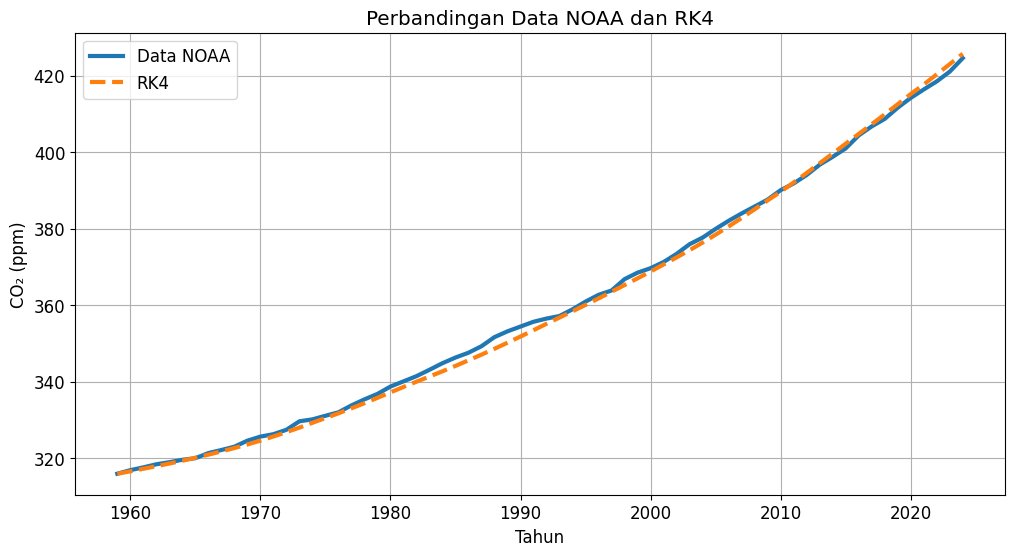

In [49]:
plt.figure(figsize=(12,6))

plt.plot(
    tahun,
    C_obs,
    linewidth=3,
    label='Data NOAA'
)

plt.plot(
    tahun,
    C_pred,
    '--',
    linewidth=3,
    label='RK4'
)

plt.xlabel("Tahun")
plt.ylabel("CO₂ (ppm)")
plt.title("Perbandingan Data NOAA dan RK4")

plt.grid(True)
plt.legend()

plt.show()

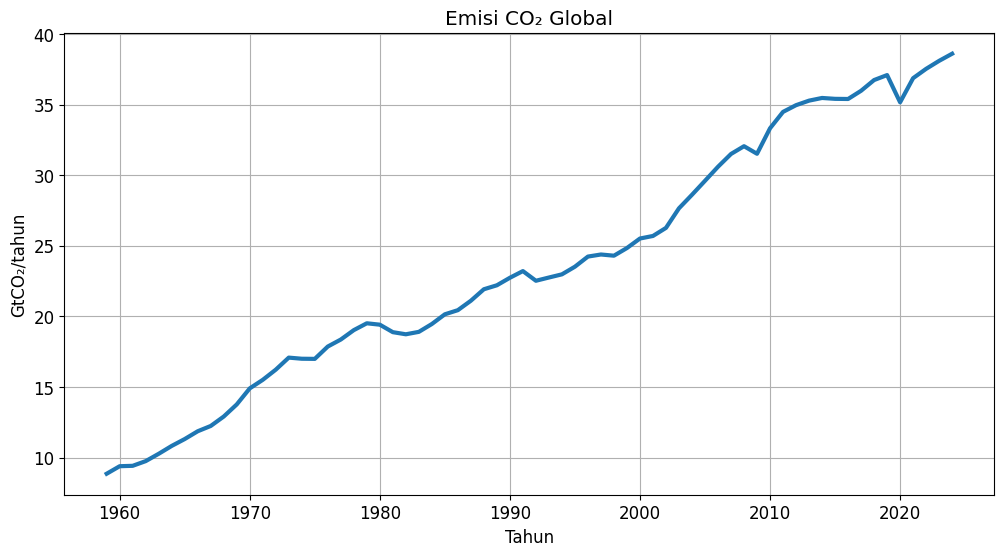

In [50]:
plt.plot(
    tahun,
    E,
    linewidth=3
)

plt.xlabel("Tahun")
plt.ylabel("GtCO₂/tahun")

plt.title(
    "Emisi CO₂ Global"
)

plt.grid(True)

plt.show()

In [51]:
hasil.to_csv(
    'hasil_simulasi_RK4_CO2.csv',
    index=False
)

print("File berhasil disimpan.")

File berhasil disimpan.


# Kesimpulan

Berdasarkan hasil simulasi yang telah dilakukan, metode Runge-Kutta Orde 4 (RK4) berhasil digunakan untuk memodelkan perubahan konsentrasi karbon dioksida (CO₂) di atmosfer berdasarkan data emisi global dan data observasi NOAA. Hasil kalibrasi parameter menghasilkan nilai α sebesar 0,079 dan nilai k sebesar 0,002 yang menunjukkan bahwa peningkatan emisi CO₂ global memiliki pengaruh yang signifikan terhadap peningkatan konsentrasi CO₂ di atmosfer, sementara proses penyerapan alami oleh lingkungan tetap terjadi meskipun dalam laju yang relatif kecil. Perbandingan antara hasil simulasi dan data observasi menunjukkan pola yang sangat mirip, sehingga model yang digunakan mampu menggambarkan tren kenaikan konsentrasi CO₂ dari tahun ke tahun dengan baik.

Nilai Root Mean Square Error (RMSE) yang diperoleh sebesar 1,269 ppm menunjukkan bahwa selisih antara hasil prediksi model dan data observasi relatif kecil. Hal ini menandakan bahwa metode RK4 memiliki tingkat akurasi yang tinggi dalam menyelesaikan model matematis yang digunakan pada penelitian ini. Selain itu, peningkatan emisi CO₂ global yang terjadi selama beberapa dekade terakhir terbukti sejalan dengan kenaikan konsentrasi CO₂ atmosfer yang diamati oleh NOAA. Dengan demikian, penelitian ini menunjukkan bahwa metode numerik, khususnya RK4, dapat digunakan secara efektif untuk menganalisis permasalahan lingkungan dan perubahan iklim, serta dapat dikembangkan lebih lanjut dengan menambahkan faktor-faktor lain agar menghasilkan model yang lebih komprehensif dan akurat.


#Saran
Penelitian selanjutnya dapat menggunakan rentang data yang lebih panjang dan memperbarui data emisi secara berkala.
Model dapat dikembangkan dengan memasukkan faktor penyerapan karbon oleh hutan dan lautan.
Metode numerik lain seperti Euler, Heun, atau Adams-Bashforth dapat dibandingkan dengan RK4 untuk mengetahui metode yang paling akurat.
Simulasi dapat diperluas untuk melakukan prediksi konsentrasi CO₂ di masa depan berdasarkan skenario emisi tertentu.